<a href="https://colab.research.google.com/github/clyv/Deequ-Practice/blob/main/notebooks/project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Setup 1 — install a version-consistent Java / Spark / Deequ stack.
#
#   PyDeequ  → accepts SPARK_VERSION=3.5 only  (see pydeequ/configs.py)
#   Deequ    → the JAR it selects is a Scala 2.12 build
#   Spark    → 3.5.x runs on Java 8 / 11 / 17
#   PySpark  → 3.5.x supports Python 3.8–3.11
#
# Spark 4.x is the trap: it needs Java 17+ AND is Scala 2.13, so it cannot load
# the Scala 2.12 Deequ JAR that PyDeequ selects. Pin Spark 3.5.
#
# Two Colab-specific hazards are handled here:
#
#   * Downgrading over an existing PySpark 4.x leaves a MIXED tree — pip does
#     not remove every file, so you end up with 3.5's pyspark/pandas/internal.py
#     importing get_column_class from a 4.0 pyspark/sql/utils.py that dropped
#     it. The package directory has to be deleted outright.
#   * The runtime must then restart, because the old modules are already in
#     sys.modules.

import os
import shutil
import sysconfig

SENTINEL = "/content/.deequ_env_ready"

if os.path.exists(SENTINEL):
    print(f"✅ Environment already prepared. Delete {SENTINEL} to rebuild it.")
else:
    !apt-get update -qq
    !apt-get install -qq -y openjdk-11-jdk-headless > /dev/null

    !pip uninstall -y -q pyspark pydeequ dataproc-spark-connect pyspark-connect

    # pip leaves files behind often enough that this matters; one stale module
    # is all it takes to break the import.
    site_dir = sysconfig.get_paths()["purelib"]
    stale = os.path.join(site_dir, "pyspark")
    if os.path.isdir(stale):
        shutil.rmtree(stale)
        print(f"removed stale pyspark tree: {stale}")

    !pip install -q "pyspark==3.5.9" "pydeequ==1.6.0"

    with open(SENTINEL, "w") as fh:
        fh.write("ok")

    print("\n" + "=" * 68)
    print("RESTARTING THE RUNTIME so the new PySpark loads cleanly.")
    print("This cell is expected to interrupt 'Run all' exactly once.")
    print("When the runtime comes back, just run everything again — this cell")
    print("will detect the sentinel and skip straight through.")
    print("=" * 68)

    import IPython

    IPython.Application.instance().kernel.do_shutdown(True)

✅ Environment already prepared. Delete /content/.deequ_env_ready to rebuild it.


In [ ]:
# Setup 2 — preflight: select a supported JDK and verify the coupled versions.
#    Spark surfaces nearly all of these as JAVA_GATEWAY_EXITED, which names no
#    cause, so resolve and check them explicitly and say what is actually wrong.
import glob
import os
import subprocess
import sys

problems = []

# --- Java -----------------------------------------------------------------
# Colab's default `java` is 21, which Spark 3.5 does not support, and apt
# installing openjdk-11 does NOT repoint /usr/bin/java. So pick the JDK
# directory directly instead of following the symlink.
jdks = (
    sorted(glob.glob("/usr/lib/jvm/java-11-openjdk*"))
    or sorted(glob.glob("/usr/lib/jvm/java-17-openjdk*"))
    or sorted(glob.glob("/usr/lib/jvm/java-8-openjdk*"))
)

if jdks:
    JAVA_HOME = jdks[0]
    os.environ["JAVA_HOME"] = JAVA_HOME
    os.environ["PATH"] = os.path.join(JAVA_HOME, "bin") + os.pathsep + os.environ["PATH"]
    banner = subprocess.run(
        [os.path.join(JAVA_HOME, "bin", "java"), "-version"],
        capture_output=True, text=True,
    ).stderr.splitlines()[0].strip()
    print(f"JAVA_HOME : {JAVA_HOME}")
    print(f"Java      : {banner}")
else:
    problems.append(
        "No supported JDK (11/17/8) found under /usr/lib/jvm. Re-run Setup 1."
    )

# --- Memory ---------------------------------------------------------------
# The pipeline is JVM-bound; if the kernel dies without a Python traceback it is
# almost always the OOM killer, so record what the runtime actually has.
total_gb = os.sysconf("SC_PAGE_SIZE") * os.sysconf("SC_PHYS_PAGES") / (1024 ** 3)
print(f"RAM       : {total_gb:.1f} GB")
if total_gb < 8:
    problems.append(
        f"Only {total_gb:.1f} GB of RAM. Three months is ~13M rows; set "
        f"MONTHS_TO_LOAD = 1 or 2 in the loader cell."
    )

# --- Python ---------------------------------------------------------------
py = sys.version_info
print(f"Python    : {py.major}.{py.minor}.{py.micro}")
if (py.major, py.minor) > (3, 11):
    problems.append(
        f"PySpark 3.5.x declares Python 3.8–3.11; this runtime is "
        f"{py.major}.{py.minor}. This pipeline runs entirely in the JVM (no "
        f"Python UDFs), so it normally works anyway — but a serialization "
        f"error later points back here."
    )

# --- PySpark --------------------------------------------------------------
import pyspark

print(f"PySpark   : {pyspark.__version__}")
if not pyspark.__version__.startswith("3.5"):
    problems.append(
        f"PyDeequ supports Spark 3.5 only; found PySpark {pyspark.__version__}. "
        "Spark 4.x needs Java 17+ and is Scala 2.13, so it cannot load the "
        "Scala 2.12 Deequ JAR."
    )

# A mixed install fails much later with a confusing ImportError from inside
# pyspark.pandas, so detect it here. get_column_class exists in 3.5 and was
# removed in 4.0, which makes it a reliable marker of a half-downgraded tree.
try:
    from pyspark.sql.utils import get_column_class  # noqa: F401
except ImportError:
    problems.append(
        "Mixed PySpark installation: pyspark.sql.utils is missing "
        "get_column_class, which PySpark 3.5's pyspark.pandas imports. A 4.x "
        "tree was downgraded in place. Delete /content/.deequ_env_ready, then "
        "re-run Setup 1 and let it restart the runtime."
    )

if problems:
    print("\n⚠️  Environment warnings:")
    for p in problems:
        print(f"   - {p}")
else:
    print("\n✅ Version matrix is consistent.")

JAVA_HOME : /usr/lib/jvm/java-11-openjdk-amd64
Java      : openjdk version "11.0.32" 2026-07-21
RAM       : 12.7 GB
Python    : 3.13.15
PySpark   : 3.5.9

⚠️  Environment warnings:
   - PySpark 3.5.x declares Python 3.8–3.11; this runtime is 3.13. This pipeline runs entirely in the JVM (no Python UDFs), so it normally works anyway — but a serialization error later points back here.


In [ ]:
# Setup 3 — fetch the data BEFORE starting Spark.
#    Downloading with the JVM already up means a multi-hundred-MB transfer runs
#    alongside a large heap reservation, and on a small runtime that is enough
#    to get the kernel OOM-killed.
#
#    TLC publishes monthly with roughly a two-month lag — a 0-byte file means
#    that month isn't published yet, so step the URLs back one month.
!wget -q "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2025-09.parquet" -O "sep_2025.parquet"
!wget -q "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2025-10.parquet" -O "oct_2025.parquet"
!wget -q "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2025-11.parquet" -O "nov_2025.parquet"
!wget -q "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv" -O "zone_lookup.csv"

from pathlib import Path

empty = [f for f in ("sep_2025.parquet", "oct_2025.parquet", "nov_2025.parquet")
         if Path(f).exists() and Path(f).stat().st_size == 0]

if empty:
    for f in empty:
        Path(f).unlink()
    print(f"⚠️  Not published yet, removed: {empty}")
    print("   Step the URLs above back a month, or let the local-file fallback handle it.")
else:
    print("✅ All files downloaded")

!ls -lh *.parquet *.csv

✅ All files downloaded
-rw-r--r-- 1 root root 68M Dec 19  2025 nov_2025.parquet
-rw-r--r-- 1 root root 72M Nov 25  2025 oct_2025.parquet
-rw-r--r-- 1 root root 70M Oct 23  2025 sep_2025.parquet
-rw-r--r-- 1 root root 13K Feb 22  2024 zone_lookup.csv


In [ ]:
# Setup 4 — Spark session.
import os
import sys

# JAVA_HOME was resolved and validated by the preflight; fail loudly here rather
# than letting Spark report it as JAVA_GATEWAY_EXITED.
if "JAVA_HOME" not in os.environ:
    raise RuntimeError("JAVA_HOME is not set — run Setup 2 (preflight) first.")

# In local[*] mode the driver JVM is ALSO the executor, so this heap is the
# entire budget for the Deequ work. The default of 1g is far too small for ~13M
# rows, but overshooting is worse: the kernel gets OOM-killed, which Colab
# reports only as "your session crashed", with no Spark error at all.
#
# So size it from the RAM this runtime actually has instead of hardcoding.
total_gb = os.sysconf("SC_PAGE_SIZE") * os.sysconf("SC_PHYS_PAGES") / (1024 ** 3)
heap_gb = max(2, min(8, int(total_gb * 0.45)))
DRIVER_MEMORY = f"{heap_gb}g"

print(f"Machine RAM   : {total_gb:.1f} GB")
print(f"Driver heap   : {DRIVER_MEMORY} (45%, leaving room for Python and the OS)")

# This must go through PYSPARK_SUBMIT_ARGS. SparkSession.builder.config() is
# applied after the JVM has launched, so spark.driver.memory set there is
# silently ignored in local mode.
os.environ["PYSPARK_SUBMIT_ARGS"] = f"--driver-memory {DRIVER_MEMORY} pyspark-shell"

# PyDeequ reads SPARK_VERSION at import time to choose its Deequ JAR, so this
# must be set BEFORE `import pydeequ`. 3.5 is the only value it accepts.
os.environ["SPARK_VERSION"] = "3.5"
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

import pydeequ
from pyspark.sql import SparkSession

# Take the coordinate from PyDeequ itself rather than hardcoding one, so the
# Python API and the JVM JAR cannot drift apart.
print(f"JAVA_HOME     : {os.environ['JAVA_HOME']}")
print(f"Deequ JAR     : {pydeequ.deequ_maven_coord}")

spark = (SparkSession.builder
    .master("local[*]")
    .config("spark.driver.host", "127.0.0.1")  # crucial for Colab stability
    .config("spark.jars.packages", pydeequ.deequ_maven_coord)
    .config("spark.jars.excludes", pydeequ.f2j_maven_coord)
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")
    # 200 shuffle partitions (the default) is pure overhead on a single node.
    .config("spark.sql.shuffle.partitions", "16")
    .config("spark.driver.maxResultSize", "1g")
    .getOrCreate())

spark.sparkContext.setLogLevel("ERROR")

# Confirm the Deequ classes actually resolved. py4j hands back a JavaPackage
# placeholder instead of raising when a class is missing, which is why the usual
# symptom is a confusing "JavaPackage object is not callable" much later.
_probe = spark._jvm.com.amazon.deequ.checks.Check
if _probe.__class__.__name__ == "JavaPackage":
    raise RuntimeError(
        "Deequ JAR did not load. The Maven download can fail silently; re-run "
        "this cell, and check the coordinate above matches the Spark version "
        "printed by the preflight."
    )

# If this reports ~1 GB, a Spark session was already alive and getOrCreate()
# reused it. Heap cannot change on a running JVM: restart the runtime.
granted = spark.sparkContext._jvm.java.lang.Runtime.getRuntime().maxMemory() / (1024 ** 3)
print(f"✅ Spark {spark.version} live, Deequ classes resolved")
print(f"   Heap granted : {granted:.1f} GB")
if granted < 2:
    print("   ⚠️  Still at the default — restart the runtime and re-run.")

Machine RAM   : 12.7 GB
Driver heap   : 5g (45%, leaving room for Python and the OS)
JAVA_HOME     : /usr/lib/jvm/java-11-openjdk-amd64
Deequ JAR     : com.amazon.deequ:deequ:2.0.8-spark-3.5
✅ Spark 3.5.9 live, Deequ classes resolved
   Heap granted : 5.0 GB


In [ ]:
from pathlib import Path

# Resolve the project root so this notebook runs unchanged from either the repo
# root (Colab: /content) or from notebooks/ (local Jupyter).
CWD = Path.cwd()
PROJECT_ROOT = CWD.parent if CWD.name == "notebooks" else CWD
print(f"📁 Project root: {PROJECT_ROOT}")

# Prefer 2025 monthly files if they exist (Colab / cloud run)
monthly_files_2025 = {
    "2025-09": "sep_2025.parquet",
    "2025-10": "oct_2025.parquet",
    "2025-11": "nov_2025.parquet",
}

# Fallback to the 2024 files if they are checked out locally
monthly_files_2024 = {
    "2024-01": "yellow_tripdata_2024-01.parquet",
    "2024-02": "yellow_tripdata_2024-02.parquet",
    "2024-03": "yellow_tripdata_2024-03.parquet",
}


def resolve(mapping):
    """Return {month: Path} for the files that exist, looking in the project
    root first and then the working directory."""
    found = {}
    for month, name in mapping.items():
        for base in (PROJECT_ROOT, CWD):
            candidate = base / name
            if candidate.exists():
                found[month] = candidate
                break
    return found


# Drop this to 2 or 1 if the runtime is memory constrained. Note that it
# changes every figure in the README's Results section, which describes a
# three-month run.
MONTHS_TO_LOAD = 3

available_2025 = resolve(monthly_files_2025)

if available_2025:
    month_to_path = available_2025
    print("📂 Using 2025 NYC Taxi parquet files:")
else:
    available_2024 = resolve(monthly_files_2024)
    if not available_2024:
        raise FileNotFoundError(
            "No NYC Taxi parquet files found. "
            "Expected either the 2025 downloads (sep_2025, oct_2025, nov_2025) "
            f"or yellow_tripdata_2024-01..03.parquet under {PROJECT_ROOT}."
        )
    month_to_path = available_2024
    print("📂 Using local NYC Taxi parquet files:")

month_to_path = dict(sorted(month_to_path.items())[:MONTHS_TO_LOAD])

for month, path in sorted(month_to_path.items()):
    print(f"  - {month}: {path}")

# Build a month -> DataFrame mapping. The per-month frames are kept alongside
# the combined frame because the metrics store analyses each month separately.
monthly_dfs = {month: spark.read.parquet(str(path)) for month, path in month_to_path.items()}

ordered_months = sorted(monthly_dfs.keys())

# Labels derived from the data actually loaded, so every report header below
# stays truthful whichever months are present.
MONTH_LABEL = " / ".join(ordered_months)
MONTH_RANGE = f"{ordered_months[0]} to {ordered_months[-1]}"
DATASET_SLUG = f"{ordered_months[0]}_{ordered_months[-1]}".replace("-", "")

# allowMissingColumns keeps the union working across a schema change — 2025
# files carry cbd_congestion_fee, earlier years do not.
df = None
for month in ordered_months:
    sdf = monthly_dfs[month]
    df = sdf if df is None else df.unionByName(sdf, allowMissingColumns=True)

# Row counts per month and overall
print("\n✅ Row counts by month:")
for month in ordered_months:
    cnt = monthly_dfs[month].count()
    print(f"  - {month}: {cnt:,} rows")

print(f"\n✅ Total combined rows: {df.count():,}")
print(f"✅ Columns: {len(df.columns)}")
print()
df.printSchema()
df.show(5, truncate=False)

📁 Project root: /content
📂 Using 2025 NYC Taxi parquet files:
  - 2025-09: /content/sep_2025.parquet
  - 2025-10: /content/oct_2025.parquet
  - 2025-11: /content/nov_2025.parquet

✅ Row counts by month:
  - 2025-09: 4,251,015 rows
  - 2025-10: 4,428,699 rows
  - 2025-11: 4,181,444 rows

✅ Total combined rows: 12,861,158
✅ Columns: 20

root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double

In [ ]:
from pydeequ.checks import Check, CheckLevel
from pydeequ.verification import VerificationSuite, VerificationResult

check = Check(spark, CheckLevel.Warning, "NYC Taxi Quality Checks")

checkResult = (VerificationSuite(spark)
    .onData(df)
    .addCheck(
        check
        # Completeness checks
        .isComplete("tpep_pickup_datetime")
        .isComplete("tpep_dropoff_datetime")
        .isComplete("fare_amount")
        # Value validity checks
        .isNonNegative("fare_amount")
        .isNonNegative("tip_amount")
        .isNonNegative("trip_distance")
        # Business rule checks
        .satisfies("trip_distance > 0", "Trip distance must be positive")
        .satisfies("fare_amount > 0", "Revenue integrity: fare must be positive")
        .satisfies("tpep_dropoff_datetime > tpep_pickup_datetime", "Dropoff must be after pickup")
        .satisfies("passenger_count >= 1 AND passenger_count <= 6", "Passenger count must be 1-6")
        .satisfies("PULocationID >= 1 AND PULocationID <= 265", "Pickup zone must be valid NYC zone")
        .satisfies("DOLocationID >= 1 AND DOLocationID <= 265", "Dropoff zone must be valid NYC zone")
    ).run()
)

print("✅ Checks complete")

✅ Checks complete


In [ ]:
results_df = VerificationResult.checkResultsAsDataFrame(spark, checkResult)
results_df.select("constraint", "constraint_status", "constraint_message").show(20, truncate=False)

+-------------------------------------------------------------------------------------------------------------------------------------------------------+-----------------+-------------------------------------------------------------------+
|constraint                                                                                                                                             |constraint_status|constraint_message                                                 |
+-------------------------------------------------------------------------------------------------------------------------------------------------------+-----------------+-------------------------------------------------------------------+
|CompletenessConstraint(Completeness(tpep_pickup_datetime,None,None))                                                                                   |Success          |                                                                   |
|CompletenessConstraint(Completeness(tpe

/usr/local/lib/python3.13/dist-packages/pyspark/sql/dataframe.py:147: UserWarning: DataFrame constructor is internal. Do not directly use it.
  warnings.warn("DataFrame constructor is internal. Do not directly use it.")


In [ ]:
import pandas as pd

pdf = results_df.toPandas()
total = len(pdf)
passed = len(pdf[pdf["constraint_status"] == "Success"])
failed = total - passed

print("=" * 55)
print(f"  NYC Taxi Data Quality Report — {MONTH_LABEL}")
print("=" * 55)
print(f"  Total checks : {total}")
print(f"  ✅ Passed    : {passed}")
print(f"  🚨 Failed    : {failed}")
print("=" * 55)
if failed > 0:
    print("\n  Failed checks:")
    for _, row in pdf[pdf["constraint_status"] != "Success"].iterrows():
        print(f"  → {row['constraint']}")

  NYC Taxi Data Quality Report — 2025-09 / 2025-10 / 2025-11
  Total checks : 12
  ✅ Passed    : 6
  🚨 Failed    : 6

  Failed checks:
  → ComplianceConstraint(Compliance(fare_amount is non-negative,COALESCE(CAST(fare_amount AS DECIMAL(20,10)), 0.0) >= 0,None,List(fare_amount),None))
  → ComplianceConstraint(Compliance(tip_amount is non-negative,COALESCE(CAST(tip_amount AS DECIMAL(20,10)), 0.0) >= 0,None,List(tip_amount),None))
  → ComplianceConstraint(Compliance(Trip distance must be positive,trip_distance > 0,None,List(),None))
  → ComplianceConstraint(Compliance(Revenue integrity: fare must be positive,fare_amount > 0,None,List(),None))
  → ComplianceConstraint(Compliance(Dropoff must be after pickup,tpep_dropoff_datetime > tpep_pickup_datetime,None,List(),None))
  → ComplianceConstraint(Compliance(Passenger count must be 1-6,passenger_count >= 1 AND passenger_count <= 6,None,List(),None))


In [ ]:
from pyspark.sql.functions import col, count, lit, when
from pyspark.sql.functions import sum as spark_sum

print("📊 Quantifying data quality issues...\n")

# Each predicate mirrors the Deequ constraint it corresponds to, so the row
# counts here and the compliance ratios above describe the same thing.
issue_predicates = {
    "Negative fare_amount": col("fare_amount") < 0,
    "Zero or negative fare": col("fare_amount") <= 0,
    "Negative tip_amount": col("tip_amount") < 0,
    "Zero trip distance": col("trip_distance") <= 0,
    # NULL is counted on purpose: Deequ's satisfies() treats a NULL predicate as
    # a violation, so excluding nulls would make this row disagree with the
    # constraint compliance ratio reported above.
    "Invalid passenger count": (
        col("passenger_count").isNull()
        | (col("passenger_count") < 1)
        | (col("passenger_count") > 6)
    ),
    "Dropoff before pickup": col("tpep_dropoff_datetime") <= col("tpep_pickup_datetime"),
}

# One pass. Counting these separately meant seven full scans of the union —
# re-reading all three parquet files each time, for identical numbers.
aggregates = [count(lit(1)).alias("total_rows")] + [
    spark_sum(when(predicate, 1).otherwise(0)).alias(f"issue_{i}")
    for i, predicate in enumerate(issue_predicates.values())
]

row = df.agg(*aggregates).collect()[0]

total_rows = int(row["total_rows"])
issues = {name: int(row[f"issue_{i}"]) for i, name in enumerate(issue_predicates)}

print(f"Total rows analyzed: {total_rows:,}\n")
print(f"{'Issue':<35} {'Rows Affected':>15} {'% of Data':>10}")
print("-" * 63)
for issue, count_val in issues.items():
    pct = (count_val / total_rows) * 100
    print(f"{issue:<35} {count_val:>15,} {pct:>9.2f}%")

📊 Quantifying data quality issues...

Total rows analyzed: 12,861,158

Issue                                 Rows Affected  % of Data
---------------------------------------------------------------
Negative fare_amount                        969,118      7.54%
Zero or negative fare                       975,362      7.58%
Negative tip_amount                             296      0.00%
Zero trip distance                          359,502      2.80%
Invalid passenger count                   3,137,285     24.39%
Dropoff before pickup                       187,267      1.46%


In [ ]:
# 3. Column Profiling — automated statistics for every column
from pydeequ.profiles import ColumnProfilerRunner
from pyspark.sql.types import (
    DoubleType,
    LongType,
    StringType,
    StructField,
    StructType,
)

print("📊 Running Deequ column profiler across all columns...\n")

profile_result = (
    ColumnProfilerRunner(spark)
    .onData(df)
    .run()
)


# PyDeequ exposes every profile field as a @property, not a method — calling
# them raises "'str' object is not callable". mean/stdDev/minimum/maximum exist
# only on NumericColumnProfile, so read those defensively.
def numeric(profile, attr):
    value = getattr(profile, attr, None)
    return float(value) if value is not None else None


# An explicit schema, with tuples in schema order. Inferring from dicts breaks
# as soon as a non-numeric column contributes no mean: Spark is left with an
# all-None column it cannot assign a type to.
profile_schema = StructType([
    StructField("column", StringType(), False),
    StructField("dataType", StringType(), True),
    StructField("completeness", DoubleType(), True),
    StructField("approxDistinctCount", LongType(), True),
    StructField("mean", DoubleType(), True),
    StructField("stddev", DoubleType(), True),
    StructField("min", DoubleType(), True),
    StructField("max", DoubleType(), True),
])

profile_rows = []
for col_name, col_profile in profile_result.profiles.items():
    profile_rows.append((
        col_name,
        str(col_profile.dataType),
        float(col_profile.completeness),
        int(col_profile.approximateNumDistinctValues),
        numeric(col_profile, "mean"),
        numeric(col_profile, "stdDev"),
        numeric(col_profile, "minimum"),
        numeric(col_profile, "maximum"),
    ))

profile_df = spark.createDataFrame(profile_rows, schema=profile_schema)

print("✅ Column profiling complete. Top-level summary (sorted by incompleteness):\n")
(profile_df
    .orderBy(profile_df.completeness.asc())
    .show(30, truncate=False))

# Keep a pandas copy handy for reporting / EDA
profile_pdf = profile_df.toPandas()

📊 Running Deequ column profiler across all columns...

✅ Column profiling complete. Top-level summary (sorted by incompleteness):

+---------------------+----------+------------------+-------------------+-------------------+-------------------+--------+---------+
|column               |dataType  |completeness      |approxDistinctCount|mean               |stddev             |min     |max      |
+---------------------+----------+------------------+-------------------+-------------------+-------------------+--------+---------+
|passenger_count      |Integral  |0.7610773462234116|10                 |1.2753464940312633 |0.6910409578709458 |0.0     |9.0      |
|Airport_fee          |Fractional|0.7610773462234116|6                  |0.14663038743255238|0.5305452247110445 |-1.75   |6.75     |
|store_and_fwd_flag   |String    |0.7610773462234116|2                  |NULL               |NULL               |NULL    |NULL     |
|RatecodeID           |Integral  |0.7610773462234116|7                 

In [ ]:
# 4. Metrics repository — persist Deequ metrics so months can be compared over
#    time. This is the piece that turns one-off checks into drift detection.
from pydeequ.repository import FileSystemMetricsRepository, ResultKey
from pydeequ.analyzers import (
    AnalysisRunner,
    Size,
    Mean,
    StandardDeviation,
    Completeness,
    Maximum,
    Minimum,
    CountDistinct,
)

metrics_dir = PROJECT_ROOT / "results" / "metrics"
reports_dir = PROJECT_ROOT / "results" / "reports"
metrics_dir.mkdir(parents=True, exist_ok=True)
reports_dir.mkdir(parents=True, exist_ok=True)

metrics_path = metrics_dir / "taxi_metrics.json"

# Swap this single line for an s3:// URI to persist metrics permanently in
# production — see docs/aws-deployment-guide.md.
repository = FileSystemMetricsRepository(spark, str(metrics_path))

print(f"✅ Metrics repository ready at: {metrics_path}")

✅ Metrics repository ready at: /content/results/metrics/taxi_metrics.json


In [ ]:
# 5. Run analysis on each month and persist metrics
for month, month_df in monthly_dfs.items():
    print(f"⏳ Analyzing {month}...")

    resultKey = ResultKey(
        spark,
        ResultKey.current_milli_time(),
        {"month": month, "dataset": "nyc_yellow_taxi"},
    )

    (
        AnalysisRunner(spark)
        .onData(month_df)
        .addAnalyzer(Size())
        .addAnalyzer(Mean("fare_amount"))
        .addAnalyzer(Mean("trip_distance"))
        .addAnalyzer(Mean("passenger_count"))
        .addAnalyzer(StandardDeviation("fare_amount"))
        .addAnalyzer(Maximum("fare_amount"))
        .addAnalyzer(Minimum("fare_amount"))
        .addAnalyzer(Completeness("passenger_count"))
        .addAnalyzer(Completeness("fare_amount"))
        .addAnalyzer(CountDistinct("PULocationID"))
        .useRepository(repository)
        .saveOrAppendResult(resultKey)
        .run()
    )

    print(f"✅ {month} saved to metrics store")

print("\n✅ All months analyzed and stored")

⏳ Analyzing 2025-09...
✅ 2025-09 saved to metrics store
⏳ Analyzing 2025-10...
✅ 2025-10 saved to metrics store
⏳ Analyzing 2025-11...
✅ 2025-11 saved to metrics store

✅ All months analyzed and stored


In [ ]:
# 6. Load the persisted metrics back out of the repository, and normalise them
#    once here so every consumer below shares the same clean frame.
metrics_df = (
    repository
    .load()
    .before(ResultKey.current_milli_time())
    .getSuccessMetricsAsDataFrame()
)

print(f"✅ Loaded {metrics_df.count()} metric rows from the repository")

metrics_pdf = metrics_df.toPandas()

# Deequ expands each ResultKey tag into its OWN column and adds dataset_date --
# see AnalysisResult.scala: `tags ... withColumn(key, lit(value))`. There is no
# `tags` dict column to unpack, so the month tag arrives as a `month` column.
if "month" not in metrics_pdf.columns:
    raise KeyError(
        "No `month` column in the metrics frame — the ResultKey tags in the "
        f"analysis cell are what create it. Columns present: {list(metrics_pdf.columns)}"
    )

# saveOrAppendResult appends, which is the whole point of a metrics store: every
# re-run of the analysis cell adds another entry per month. Collapse to the most
# recent per (metric, column, month) so each series has exactly one value per
# month -- otherwise reindexing hits duplicate labels.
row_count_before = len(metrics_pdf)

if "dataset_date" in metrics_pdf.columns:
    metrics_pdf = metrics_pdf.sort_values("dataset_date")

metrics_pdf = metrics_pdf.drop_duplicates(
    subset=["name", "instance", "month"], keep="last"
)

if len(metrics_pdf) < row_count_before:
    print(
        f"   {row_count_before} rows collapsed to {len(metrics_pdf)}; the "
        f"repository holds results from more than one run."
    )

# The repository persists across runs, so it can hold months that are not in
# this run's data (an earlier 2024 fallback, say). Reindexing against the
# current months would then yield all-NaN series and a drift report full of
# "nan" rather than an error -- so say so plainly here instead.
expected_months = sorted(monthly_dfs.keys())
present_months = sorted(metrics_pdf["month"].dropna().unique())

missing = [m for m in expected_months if m not in present_months]
if missing:
    print(f"   ⚠️  No metrics stored for {missing}.")
    print(f"      Re-run the analysis cell (step 5) before the report cells.")

extra = [m for m in present_months if m not in expected_months]
if extra:
    print(f"   note: repository also holds {extra} from an earlier run; ignored.")

print()
print(
    metrics_pdf
    .sort_values(["month", "name", "instance"])
    .to_string(index=False)
)

✅ Loaded 60 metric rows from the repository
   60 rows collapsed to 30; the repository holds results from more than one run.

 entity        instance              name         value  dataset_date   month         dataset
 Column     fare_amount      Completeness  1.000000e+00 1788946992243 2025-09 nyc_yellow_taxi
 Column passenger_count      Completeness  7.489552e-01 1788946992243 2025-09 nyc_yellow_taxi
 Column    PULocationID     CountDistinct  2.590000e+02 1788946992243 2025-09 nyc_yellow_taxi
 Column     fare_amount           Maximum  3.238003e+05 1788946992243 2025-09 nyc_yellow_taxi
 Column     fare_amount              Mean  1.920400e+01 1788946992243 2025-09 nyc_yellow_taxi
 Column passenger_count              Mean  1.264231e+00 1788946992243 2025-09 nyc_yellow_taxi
 Column   trip_distance              Mean  6.839378e+00 1788946992243 2025-09 nyc_yellow_taxi
 Column     fare_amount           Minimum -9.980000e+02 1788946992243 2025-09 nyc_yellow_taxi
Dataset               *     

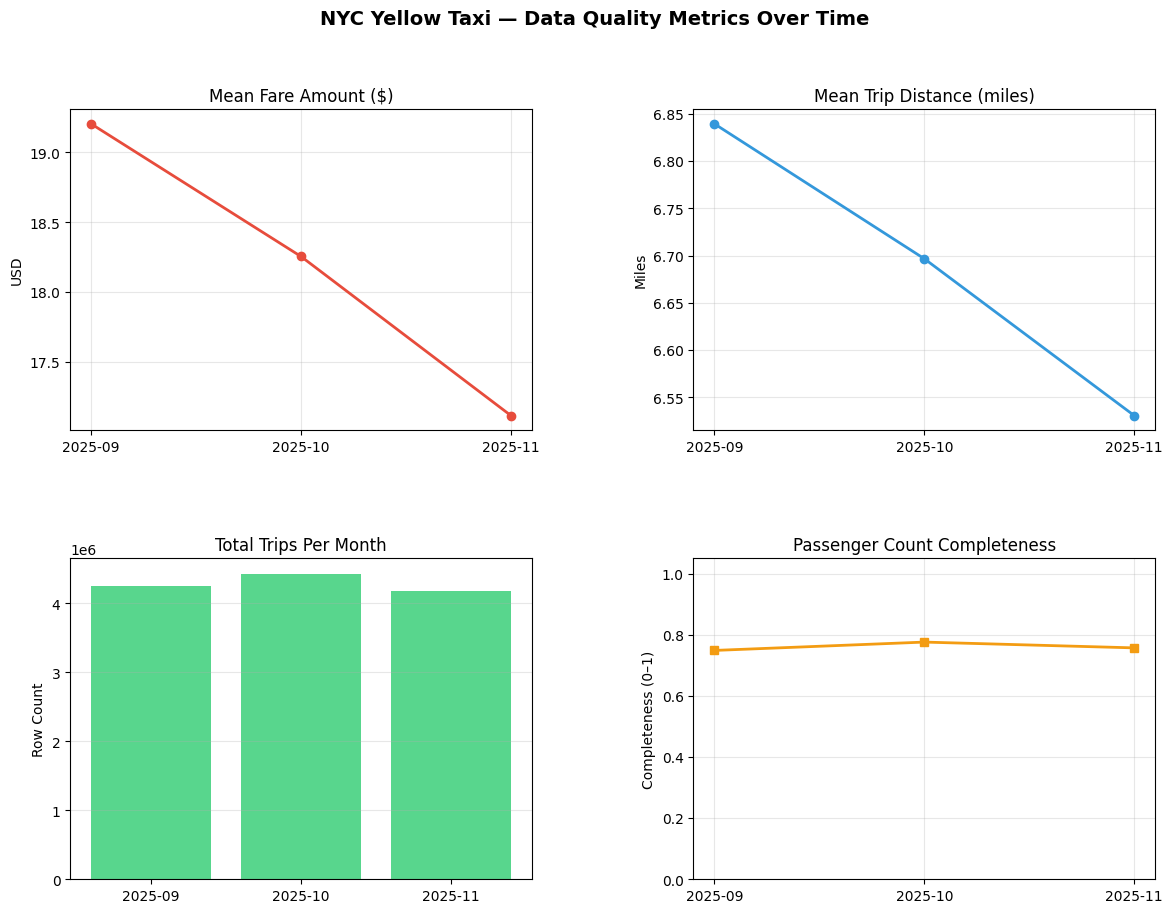

✅ Chart saved to /content/results/metrics/anomaly_trends.png


In [ ]:
# 7. Visualize metric trends across months (drift / anomalies)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# metrics_pdf was normalised in the previous cell: one row per
# (metric, column, month), with `month` coming from the ResultKey tag.
months_label = sorted(monthly_dfs.keys())


def get_metric(name, instance):
    """Return this metric's values in month order, NaN where a month is absent."""
    series = (
        metrics_pdf[
            (metrics_pdf["name"] == name)
            & (metrics_pdf["instance"] == instance)
        ]
        .set_index("month")["value"]
        .reindex(months_label)
    )
    return series


mean_fare    = get_metric("Mean", "fare_amount")
mean_dist    = get_metric("Mean", "trip_distance")
row_count    = get_metric("Size", "*")
completeness = get_metric("Completeness", "passenger_count")

fig = plt.figure(figsize=(14, 10))
fig.suptitle(
    "NYC Yellow Taxi — Data Quality Metrics Over Time",
    fontsize=14,
    fontweight="bold",
    y=0.98,
)
gs = gridspec.GridSpec(2, 2, hspace=0.4, wspace=0.35)

# Plot 1 — Mean Fare
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(months_label, mean_fare.values, marker="o", color="#e74c3c", linewidth=2)
ax1.set_title("Mean Fare Amount ($)")
ax1.set_ylabel("USD")
ax1.grid(True, alpha=0.3)

# Plot 2 — Mean Trip Distance
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(months_label, mean_dist.values, marker="o", color="#3498db", linewidth=2)
ax2.set_title("Mean Trip Distance (miles)")
ax2.set_ylabel("Miles")
ax2.grid(True, alpha=0.3)

# Plot 3 — Row Count
ax3 = fig.add_subplot(gs[1, 0])
ax3.bar(months_label, row_count.values, color="#2ecc71", alpha=0.8)
ax3.set_title("Total Trips Per Month")
ax3.set_ylabel("Row Count")
ax3.grid(True, alpha=0.3, axis="y")

# Plot 4 — Passenger Count Completeness
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(
    months_label,
    completeness.values,
    marker="s",
    color="#f39c12",
    linewidth=2,
)
ax4.set_title("Passenger Count Completeness")
ax4.set_ylabel("Completeness (0–1)")
ax4.set_ylim(0, 1.05)
ax4.grid(True, alpha=0.3)

output_chart_path = os.path.join(metrics_dir, "anomaly_trends.png")
plt.savefig(output_chart_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Chart saved to {output_chart_path}")

In [ ]:
# 8. Consolidated human-readable quality + drift report

print("=" * 70)
print("NYC Taxi Data Quality & Drift Summary")
print("=" * 70)

# Constraint check summary from earlier cells
pdf_checks = results_df.toPandas()
num_checks = len(pdf_checks)
num_passed = (pdf_checks["constraint_status"] == "Success").sum()
num_failed = num_checks - num_passed

print(f"Total constraints evaluated : {num_checks}")
print(f"✅ Constraints passed       : {num_passed}")
print(f"🚨 Constraints failed       : {num_failed}")

if num_failed > 0:
    print("\nFailed constraints:")
    for _, row in pdf_checks[pdf_checks["constraint_status"] != "Success"].iterrows():
        print(f"  → {row['constraint']}")

print("\nKey issue counts (from full-data scan):")

for name, count_val in issues.items():
    pct = (count_val / total_rows) * 100 if total_rows else 0.0
    print(f"  - {name:<30} {count_val:>10,} rows  ({pct:>6.2f}% of data)")

# Drift narrative, from the frame normalised in the load cell.
months_label = sorted(monthly_dfs.keys())


def metric_series(name, instance):
    return (
        metrics_pdf[
            (metrics_pdf["name"] == name)
            & (metrics_pdf["instance"] == instance)
        ]
        .set_index("month")["value"]
        .reindex(months_label)
    )


try:
    mean_fare_series = metric_series("Mean", "fare_amount")
    first_fare = float(mean_fare_series.iloc[0])
    last_fare = float(mean_fare_series.iloc[-1])
    pct_change_fare = ((last_fare - first_fare) / first_fare) * 100 if first_fare else 0.0

    print("\nDrift highlights:")
    print(
        f"  - Mean fare changed from ${first_fare:0.2f} to ${last_fare:0.2f} "
        f"across {len(months_label)} months ({pct_change_fare:+0.2f}% change)"
    )

    mean_dist_series = metric_series("Mean", "trip_distance")
    first_dist = float(mean_dist_series.iloc[0])
    last_dist = float(mean_dist_series.iloc[-1])
    pct_change_dist = ((last_dist - first_dist) / first_dist) * 100 if first_dist else 0.0

    print(
        f"  - Mean trip distance changed from {first_dist:0.2f} to "
        f"{last_dist:0.2f} miles ({pct_change_dist:+0.2f}% change)"
    )

    compl_series = metric_series("Completeness", "passenger_count")
    first_compl = float(compl_series.iloc[0])
    last_compl = float(compl_series.iloc[-1])
    delta_compl = last_compl - first_compl

    print(
        f"  - Passenger count completeness moved from {first_compl:0.4f} to "
        f"{last_compl:0.4f} ({delta_compl:+0.4f} absolute change)"
    )
except Exception as exc:
    # Report the actual reason: a silent "could not compute" here is what let
    # the metrics-store bugs go unnoticed for so long.
    print("\n(Drift narrative could not be computed.)")
    print(f"  {type(exc).__name__}: {exc}")
    print(f"  months expected : {months_label}")
    print(f"  months present  : {sorted(metrics_pdf['month'].dropna().unique())}")

print("\n✅ Consolidated quality and drift report ready for README / LinkedIn narrative.")

NYC Taxi Data Quality & Drift Summary
Total constraints evaluated : 12
✅ Constraints passed       : 6
🚨 Constraints failed       : 6

Failed constraints:
  → ComplianceConstraint(Compliance(fare_amount is non-negative,COALESCE(CAST(fare_amount AS DECIMAL(20,10)), 0.0) >= 0,None,List(fare_amount),None))
  → ComplianceConstraint(Compliance(tip_amount is non-negative,COALESCE(CAST(tip_amount AS DECIMAL(20,10)), 0.0) >= 0,None,List(tip_amount),None))
  → ComplianceConstraint(Compliance(Trip distance must be positive,trip_distance > 0,None,List(),None))
  → ComplianceConstraint(Compliance(Revenue integrity: fare must be positive,fare_amount > 0,None,List(),None))
  → ComplianceConstraint(Compliance(Dropoff must be after pickup,tpep_dropoff_datetime > tpep_pickup_datetime,None,List(),None))
  → ComplianceConstraint(Compliance(Passenger count must be 1-6,passenger_count >= 1 AND passenger_count <= 6,None,List(),None))

Key issue counts (from full-data scan):
  - Negative fare_amount          

In [ ]:
# 9. Export machine-readable artefacts + a paste-ready README block.
import pandas as pd

constraint_csv = reports_dir / f"constraint_results_{DATASET_SLUG}.csv"
pdf_checks.to_csv(constraint_csv, index=False)

profile_csv = reports_dir / f"column_profile_{DATASET_SLUG}.csv"
profile_pdf.to_csv(profile_csv, index=False)

issues_pdf = pd.DataFrame(
    [
        {
            "issue": name,
            "rows_affected": int(count_val),
            "pct_of_data": round((count_val / total_rows) * 100, 4),
        }
        for name, count_val in issues.items()
    ]
)
issues_csv = reports_dir / f"issue_counts_{DATASET_SLUG}.csv"
issues_pdf.to_csv(issues_csv, index=False)

metrics_csv = reports_dir / f"metrics_{DATASET_SLUG}.csv"
metrics_pdf.to_csv(metrics_csv, index=False)


def fmt(name, spec):
    """Format a drift value by name, tolerating the metrics repository having
    been only partially populated."""
    try:
        return format(float(globals().get(name)), spec)
    except (TypeError, ValueError):
        return "n/a"


issue_label = {
    "Invalid passenger count": "Invalid passenger count (outside 1–6)",
    "Zero or negative fare": "Zero or negative fare amount",
    "Negative fare_amount": "Negative fare amount",
    "Zero trip distance": "Zero trip distance",
    "Dropoff before pickup": "Dropoff recorded before pickup",
    "Negative tip_amount": "Negative tip amount",
}
issue_order = [
    "Invalid passenger count",
    "Zero or negative fare",
    "Negative fare_amount",
    "Zero trip distance",
    "Dropoff before pickup",
    "Negative tip_amount",
]

lines = [
    "## 📊 Results",
    "",
    "| Metric | Value |",
    "|---|---|",
    f"| Months analyzed | {', '.join(ordered_months)} |",
    f"| Total rows validated | {total_rows:,} |",
    f"| Constraint checks run | {num_checks} |",
    f"| ✅ Checks passed | {num_passed} |",
    f"| 🚨 Checks failed | {num_failed} |",
    "",
    "### Real Data Quality Issues Found",
    "",
    "| Issue | Rows Affected | % of Data |",
    "|---|---|---|",
]

for key in issue_order:
    if key not in issues:
        continue
    rows_affected = issues[key]
    pct = (rows_affected / total_rows) * 100 if total_rows else 0.0
    lines.append(f"| {issue_label[key]} | {rows_affected:,} | {pct:.2f}% |")

lines += [
    "",
    f"### Drift Detected Across {len(ordered_months)} Months",
    f"- Mean fare amount: ${fmt('first_fare', '.2f')} → ${fmt('last_fare', '.2f')} "
    f"({fmt('pct_change_fare', '+.2f')}% change)",
    f"- Mean trip distance: {fmt('first_dist', '.2f')} → {fmt('last_dist', '.2f')} miles "
    f"({fmt('pct_change_dist', '+.2f')}% change)",
    f"- Passenger count completeness: {fmt('first_compl', '.4f')} → "
    f"{fmt('last_compl', '.4f')}",
    "",
]

snippet_path = reports_dir / "README_results_snippet.md"
snippet_path.write_text("\n".join(lines), encoding="utf-8")

print("✅ Exported:")
for p in (constraint_csv, profile_csv, issues_csv, metrics_csv, snippet_path):
    print(f"  - {p.relative_to(PROJECT_ROOT)}")

print("\n" + "=" * 70)
print("Paste the block below straight into README.md")
print("=" * 70)
print("\n".join(lines))

✅ Exported:
  - results/reports/constraint_results_202509_202511.csv
  - results/reports/column_profile_202509_202511.csv
  - results/reports/issue_counts_202509_202511.csv
  - results/reports/metrics_202509_202511.csv
  - results/reports/README_results_snippet.md

Paste the block below straight into README.md
## 📊 Results

| Metric | Value |
|---|---|
| Months analyzed | 2025-09, 2025-10, 2025-11 |
| Total rows validated | 12,861,158 |
| Constraint checks run | 12 |
| ✅ Checks passed | 6 |
| 🚨 Checks failed | 6 |

### Real Data Quality Issues Found

| Issue | Rows Affected | % of Data |
|---|---|---|
| Invalid passenger count (outside 1–6) | 3,137,285 | 24.39% |
| Zero or negative fare amount | 975,362 | 7.58% |
| Negative fare amount | 969,118 | 7.54% |
| Zero trip distance | 359,502 | 2.80% |
| Dropoff recorded before pickup | 187,267 | 1.46% |
| Negative tip amount | 296 | 0.00% |

### Drift Detected Across 3 Months
- Mean fare amount: $19.20 → $17.12 (-10.86% change)
- Mean trip d

In [48]:
# 10. Root cause — are these six issues actually six problems?
#
#     Deequ reports WHAT fails. It does not say whether the failures are
#     independent, and that is the difference between six tickets and one.
from functools import reduce
from operator import and_, or_

from pyspark.sql.functions import col, lit, when
from pyspark.sql.functions import count as spark_count
from pyspark.sql.functions import sum as spark_sum

# Columns that look like they go missing together.
CLUSTER_COLUMNS = [
    "passenger_count",
    "congestion_surcharge",
    "RatecodeID",
    "store_and_fwd_flag",
    "Airport_fee",
]
cluster_columns = [c for c in CLUSTER_COLUMNS if c in df.columns]

all_null = reduce(and_, [col(c).isNull() for c in cluster_columns])
any_null = reduce(or_, [col(c).isNull() for c in cluster_columns])

# payment_type 0 is not in the TLC data dictionary, which defines 1-6.
marker = col("payment_type") == 0

profile = df.agg(
    spark_count(lit(1)).alias("rows"),
    *[
        spark_sum(col(c).isNull().cast("long")).alias(f"null__{c}")
        for c in cluster_columns
    ],
    spark_sum(all_null.cast("long")).alias("all_null"),
    spark_sum(any_null.cast("long")).alias("any_null"),
    spark_sum(marker.cast("long")).alias("payment_type_zero"),
    spark_sum((all_null & marker).cast("long")).alias("both"),
).collect()[0]

rows = profile["rows"]

print("=" * 72)
print("Co-missingness: which columns go NULL together?")
print("=" * 72)
for c in cluster_columns:
    k = profile[f"null__{c}"]
    print(f"  {c:<24} {k:>12,}  ({k / rows * 100:5.2f}%)")

print(f"\n  null in ANY of them   {profile['any_null']:>12,}")
print(f"  null in ALL of them   {profile['all_null']:>12,}")

if profile["any_null"] == profile["all_null"]:
    print("\n  ANY == ALL: these columns are never missing individually. They are")
    print("  absent as a block, which points at one upstream feed rather than")
    print("  five independent collection problems.")

print(f"\n  payment_type == 0 (invalid per the TLC spec, which defines 1-6)")
print(f"    rows                {profile['payment_type_zero']:>12,}")
print(f"    also all-NULL       {profile['both']:>12,}")
if profile["payment_type_zero"] == profile["all_null"] == profile["both"]:
    print("    -> the same rows exactly. payment_type 0 is this feed's signature.")

cluster_rows = profile["all_null"]
print(f"\n  Suspect feed: {cluster_rows:,} rows ({cluster_rows / rows * 100:.2f}% of the dataset)")

# ---- how much of each issue does that one feed explain? ------------------
# issue_predicates was defined in the quantification cell above.
aggregates = []
for i, predicate in enumerate(issue_predicates.values()):
    aggregates.append(spark_sum(when(predicate, 1).otherwise(0)).alias(f"total__{i}"))
    aggregates.append(
        spark_sum(when(predicate & all_null, 1).otherwise(0)).alias(f"cluster__{i}")
    )

attribution = df.agg(*aggregates).collect()[0]

print("\n" + "=" * 72)
print("How much of each issue traces back to that one feed?")
print("=" * 72)
print(f"  {'issue':<26}{'total':>12}{'from feed':>12}{'share':>9}")
print("  " + "-" * 57)

attributable = []
for i, name in enumerate(issue_predicates):
    total = attribution[f"total__{i}"]
    from_feed = attribution[f"cluster__{i}"]
    share = (from_feed / total * 100) if total else 0.0
    print(f"  {name:<26}{total:>12,}{from_feed:>12,}{share:>8.1f}%")
    if share >= 50:
        attributable.append(name)

print(
    f"\n  {len(attributable)} of {len(issue_predicates)} issues are majority-explained "
    f"by this single feed:"
)
for name in attributable:
    print(f"    - {name}")
print(
    "\n  The remainder (timestamp ordering, negative tips) are genuinely separate\n"
    "  defects and need their own fix."
)

Co-missingness: which columns go NULL together?
  passenger_count             3,072,822  (23.89%)
  congestion_surcharge        3,072,822  (23.89%)
  RatecodeID                  3,072,822  (23.89%)
  store_and_fwd_flag          3,072,822  (23.89%)
  Airport_fee                 3,072,822  (23.89%)

  null in ANY of them      3,072,822
  null in ALL of them      3,072,822

  ANY == ALL: these columns are never missing individually. They are
  absent as a block, which points at one upstream feed rather than
  five independent collection problems.

  payment_type == 0 (invalid per the TLC spec, which defines 1-6)
    rows                   3,072,822
    also all-NULL          3,072,822
    -> the same rows exactly. payment_type 0 is this feed's signature.

  Suspect feed: 3,072,822 rows (23.89% of the dataset)

How much of each issue traces back to that one feed?
  issue                            total   from feed    share
  ---------------------------------------------------------
  Nega

In [49]:
# 11. Clean and revalidate — closing the arc: detect → quantify → clean → revalidate.
#
#     Which rows to drop is a judgement call, not a formality, so compare two
#     strategies before picking one.
import re

from pyspark.sql.functions import col

trip_validity = (
    (col("fare_amount") > 0)
    & (col("trip_distance") > 0)
    & (col("tpep_dropoff_datetime") > col("tpep_pickup_datetime"))
    & (col("tip_amount") >= 0)
)
passenger_validity = (
    col("passenger_count").isNotNull()
    & (col("passenger_count") >= 1)
    & (col("passenger_count") <= 6)
)

strict = df.filter(trip_validity & passenger_validity)
lenient = df.filter(trip_validity)

strict_rows = strict.count()
lenient_rows = lenient.count()

print("=" * 72)
print("Two cleaning strategies")
print("=" * 72)
print(f"  raw rows                                  {total_rows:>12,}")
print(
    f"  strict   (all 12 constraints)             {strict_rows:>12,}  "
    f"keeps {strict_rows / total_rows * 100:5.2f}%"
)
print(
    f"  lenient  (trip validity, keep NULL pax)   {lenient_rows:>12,}  "
    f"keeps {lenient_rows / total_rows * 100:5.2f}%"
)
print(
    f"\n  Strict discards {lenient_rows - strict_rows:,} extra rows whose only fault is a\n"
    f"  missing passenger_count — a field that says nothing about whether the\n"
    f"  trip itself is valid. Those trips have a real fare, distance and\n"
    f"  timestamps, so dropping them would throw away good revenue data to\n"
    f"  satisfy a constraint about a passenger headcount."
)

df_clean = lenient
print(f"\n  → proceeding with the lenient set: {lenient_rows:,} rows")

# ---- revalidate: the same suite, against the cleaned frame ---------------
print("\nRe-running the identical VerificationSuite on the cleaned data...\n")

clean_check = Check(spark, CheckLevel.Warning, "NYC Taxi Quality Checks (cleaned)")

clean_result = (VerificationSuite(spark)
    .onData(df_clean)
    .addCheck(
        clean_check
        .isComplete("tpep_pickup_datetime")
        .isComplete("tpep_dropoff_datetime")
        .isComplete("fare_amount")
        .isNonNegative("fare_amount")
        .isNonNegative("tip_amount")
        .isNonNegative("trip_distance")
        .satisfies("trip_distance > 0", "Trip distance must be positive")
        .satisfies("fare_amount > 0", "Revenue integrity: fare must be positive")
        .satisfies("tpep_dropoff_datetime > tpep_pickup_datetime", "Dropoff must be after pickup")
        .satisfies("passenger_count >= 1 AND passenger_count <= 6", "Passenger count must be 1-6")
        .satisfies("PULocationID >= 1 AND PULocationID <= 265", "Pickup zone must be valid NYC zone")
        .satisfies("DOLocationID >= 1 AND DOLocationID <= 265", "Dropoff zone must be valid NYC zone")
    ).run()
)

clean_results_df = VerificationResult.checkResultsAsDataFrame(spark, clean_result)


def compliance_table(spark_df):
    """Deequ reports the compliance ratio inside constraint_message on failure;
    a Success means the assertion held, which for these checks is 1.0."""
    out = spark_df.toPandas()[["constraint", "constraint_status", "constraint_message"]]
    out = out.copy()
    value = out["constraint_message"].str.extract(r"Value:\s*([0-9.eE+-]+)")[0]
    out["compliance"] = pd.to_numeric(value, errors="coerce")
    out.loc[out["constraint_status"] == "Success", "compliance"] = 1.0
    # Deequ constraint strings are deeply nested, e.g.
    #   ComplianceConstraint(Compliance(Trip distance must be positive,...))
    # Pull out the readable first argument rather than truncating the wrapper.
    readable = out["constraint"].str.extract(
        r"\((?:Completeness|Compliance|Uniqueness|Size)\(([^,)]+)"
    )[0]
    out["short"] = readable.fillna(out["constraint"]).str.slice(0, 46)
    return out


before = compliance_table(results_df)
after = compliance_table(clean_results_df)

merged = before.merge(after, on="constraint", suffixes=("_before", "_after"))

print("=" * 92)
print(f"{'constraint':<48}{'before':>10}{'after':>10}{'change':>10}{'status':>12}")
print("=" * 92)
for _, r in merged.iterrows():
    b, a = r["compliance_before"], r["compliance_after"]
    delta = a - b
    moved = (
        "fixed" if r["constraint_status_before"] != "Success" and r["constraint_status_after"] == "Success"
        else ("still failing" if r["constraint_status_after"] != "Success" else "was passing")
    )
    print(f"{r['short_before']:<48}{b:>10.4f}{a:>10.4f}{delta:>+10.4f}{moved:>12}")

passed_before = (before["constraint_status"] == "Success").sum()
passed_after = (after["constraint_status"] == "Success").sum()

print("=" * 92)
print(f"  constraints passing: {passed_before}/{len(before)} before → {passed_after}/{len(after)} after")
print(
    f"  rows retained      : {lenient_rows:,} of {total_rows:,} "
    f"({lenient_rows / total_rows * 100:.2f}%)"
)
print(
    "\n  passenger_count is expected to still fail: the lenient strategy keeps\n"
    "  those rows deliberately. That is the honest outcome — cleaning fixed the\n"
    "  trip-level defects, and the missing-field problem belongs upstream, not\n"
    "  in a filter."
)

Two cleaning strategies
  raw rows                                    12,861,158
  strict   (all 12 constraints)                9,230,244  keeps 71.77%
  lenient  (trip validity, keep NULL pax)     11,426,085  keeps 88.84%

  Strict discards 2,195,841 extra rows whose only fault is a
  missing passenger_count — a field that says nothing about whether the
  trip itself is valid. Those trips have a real fare, distance and
  timestamps, so dropping them would throw away good revenue data to
  satisfy a constraint about a passenger headcount.

  → proceeding with the lenient set: 11,426,085 rows

Re-running the identical VerificationSuite on the cleaned data...

constraint                                          before     after    change      status
tpep_pickup_datetime                                1.0000    1.0000   +0.0000 was passing
tpep_dropoff_datetime                               1.0000    1.0000   +0.0000 was passing
fare_amount                                         1.0000  

/usr/local/lib/python3.13/dist-packages/pyspark/sql/dataframe.py:147: UserWarning: DataFrame constructor is internal. Do not directly use it.
  warnings.warn("DataFrame constructor is internal. Do not directly use it.")


In [50]:
# 12. Congestion pricing — what the new cbd_congestion_fee column shows.
#
#     NYC began charging for entry to the Manhattan CBD in 2025, and the fee
#     lands in the trip record as its own column. It sits alongside the older
#     congestion_surcharge, so the two are easy to confuse.
from pyspark.sql.functions import avg, col, count, expr, hour, lit, round as sround
from pyspark.sql.functions import sum as spark_sum
from pyspark.sql.functions import when

if "cbd_congestion_fee" not in df.columns:
    print("cbd_congestion_fee is absent — this section needs 2025 data.")
else:
    # ---- incidence and revenue, on the RAW frame so refunds stay visible ---
    fee = col("cbd_congestion_fee")
    stats = df.agg(
        count(lit(1)).alias("rows"),
        spark_sum(when(fee > 0, 1).otherwise(0)).alias("charged"),
        spark_sum(when(fee == 0, 1).otherwise(0)).alias("zero"),
        spark_sum(when(fee < 0, 1).otherwise(0)).alias("refunded"),
        spark_sum(when(fee > 0, fee).otherwise(0.0)).alias("collected"),
        spark_sum(when(fee < 0, fee).otherwise(0.0)).alias("returned"),
        spark_sum(when(col("congestion_surcharge") > 0, 1).otherwise(0)).alias("legacy"),
    ).collect()[0]

    rows = stats["rows"]
    print("=" * 72)
    print("CBD congestion fee — incidence")
    print("=" * 72)
    print(f"  charged (> 0)      {stats['charged']:>12,}  ({stats['charged'] / rows * 100:5.2f}%)")
    print(f"  not charged (= 0)  {stats['zero']:>12,}  ({stats['zero'] / rows * 100:5.2f}%)")
    print(f"  refunded (< 0)     {stats['refunded']:>12,}  ({stats['refunded'] / rows * 100:5.2f}%)")
    print(f"\n  collected          ${stats['collected']:>14,.0f}")
    print(f"  returned           ${stats['returned']:>14,.0f}")
    print(f"  net                ${stats['collected'] + stats['returned']:>14,.0f}")
    print(
        f"\n  For contrast, the older congestion_surcharge applies to "
        f"{stats['legacy'] / rows * 100:.2f}% of trips.\n"
        f"  They are separate charges: the surcharge predates 2025 congestion\n"
        f"  pricing, and a trip can carry both."
    )

    # ---- per month --------------------------------------------------------
    print("\n" + "=" * 72)
    print("By month")
    print("=" * 72)
    print(f"  {'month':<10}{'trips':>12}{'charged':>12}{'share':>9}{'collected':>14}")
    print("  " + "-" * 55)
    for month in ordered_months:
        m = monthly_dfs[month].agg(
            count(lit(1)).alias("rows"),
            spark_sum(when(fee > 0, 1).otherwise(0)).alias("charged"),
            spark_sum(when(fee > 0, fee).otherwise(0.0)).alias("collected"),
        ).collect()[0]
        print(
            f"  {month:<10}{m['rows']:>12,}{m['charged']:>12,}"
            f"{m['charged'] / m['rows'] * 100:>8.2f}%{m['collected']:>14,.0f}"
        )

    # ---- economics, on the CLEANED frame ---------------------------------
    # df_clean already dropped the refund rows (a negative fee almost always
    # accompanies a negative fare), so these averages describe real trips.
    print("\n" + "=" * 72)
    print("Trips that pay the CBD fee vs trips that do not (cleaned data)")
    print("=" * 72)

    economics = (
        df_clean
        .withColumn("pays_cbd", col("cbd_congestion_fee") > 0)
        .groupBy("pays_cbd")
        .agg(
            count(lit(1)).alias("trips"),
            sround(avg("fare_amount"), 2).alias("mean_fare"),
            sround(avg("trip_distance"), 2).alias("mean_miles"),
            sround(avg("total_amount"), 2).alias("mean_total"),
            sround(avg("tip_amount"), 2).alias("mean_tip"),
            sround(expr("percentile_approx(fare_amount / trip_distance, 0.5)"), 2)
            .alias("median_fare_per_mile"),
        )
        .orderBy(col("pays_cbd").desc())
    )
    economics.show(truncate=False)

    print(
        "  Congestion-zone trips are shorter but cost more per mile, which is\n"
        "  what a cordon charge is designed to do. They also tip better, so the\n"
        "  higher per-mile cost is not suppressing gratuities."
    )

    # ---- when does demand peak? ------------------------------------------
    print("=" * 72)
    print("Pickup demand by hour (cleaned data)")
    print("=" * 72)
    hourly = (
        df_clean
        .groupBy(hour("tpep_pickup_datetime").alias("hour"))
        .agg(count(lit(1)).alias("trips"))
        .orderBy("hour")
        .toPandas()
    )
    peak = hourly.loc[hourly["trips"].idxmax()]
    trough = hourly.loc[hourly["trips"].idxmin()]
    scale = hourly["trips"].max()
    for _, r in hourly.iterrows():
        bar = "█" * int(r["trips"] / scale * 44)
        print(f"  {int(r['hour']):02d}:00 {r['trips']:>9,} {bar}")
    print(
        f"\n  Peak {int(peak['hour']):02d}:00 ({peak['trips']:,}), "
        f"trough {int(trough['hour']):02d}:00 ({trough['trips']:,}) — "
        f"a {peak['trips'] / trough['trips']:.1f}x swing."
    )

    # ---- busiest pickup zones, using the lookup table --------------------
    zone_path = PROJECT_ROOT / "zone_lookup.csv"
    if not zone_path.exists():
        zone_path = CWD / "zone_lookup.csv"

    if zone_path.exists():
        zones = (
            spark.read.csv(str(zone_path), header=True, inferSchema=True)
            .select(
                col("LocationID").cast("int").alias("PULocationID"),
                col("Borough"),
                col("Zone"),
            )
        )
        print("\n" + "=" * 72)
        print("Busiest pickup zones for trips paying the CBD fee")
        print("=" * 72)
        (
            df_clean
            .filter(col("cbd_congestion_fee") > 0)
            .groupBy("PULocationID")
            .agg(count(lit(1)).alias("trips"))
            .join(zones, on="PULocationID", how="left")
            .orderBy(col("trips").desc())
            .select("Borough", "Zone", "trips")
            .show(10, truncate=False)
        )
    else:
        print("\n(zone_lookup.csv not found — skipping the zone breakdown.)")

CBD congestion fee — incidence
  charged (> 0)         9,303,740  (72.34%)
  not charged (= 0)     3,427,510  (26.65%)
  refunded (< 0)          129,908  ( 1.01%)

  collected          $     6,977,837
  returned           $       -97,431
  net                $     6,880,406

  For contrast, the older congestion_surcharge applies to 67.26% of trips.
  They are separate charges: the surcharge predates 2025 congestion
  pricing, and a trip can carry both.

By month
  month            trips     charged    share     collected
  -------------------------------------------------------
  2025-09      4,251,015   3,080,638   72.47%     2,310,510
  2025-10      4,428,699   3,208,179   72.44%     2,406,134
  2025-11      4,181,444   3,014,923   72.10%     2,261,192

Trips that pay the CBD fee vs trips that do not (cleaned data)
+--------+-------+---------+----------+----------+--------+--------------------+
|pays_cbd|trips  |mean_fare|mean_miles|mean_total|mean_tip|median_fare_per_mile|
+--------

In [ ]:
# 13. Anomaly detection — Deequ's own API, not an eyeballed chart.
#
#     Steps 5–7 persist metrics and plot them, but a human still has to notice
#     the drift. addAnomalyCheck compares a new batch against the history in a
#     metrics repository and FAILS a check when it deviates, which is the part
#     that can run unattended in a pipeline.
from pydeequ.anomaly_detection import RelativeRateOfChangeStrategy

# A throwaway repository, so the demonstration cannot pollute the real store.
demo_path = metrics_dir / "anomaly_demo.json"
if demo_path.exists():
    demo_path.unlink()
demo_repository = FileSystemMetricsRepository(spark, str(demo_path))

history_months = ordered_months[:-1]
new_month = ordered_months[-1]

print(f"History   : {', '.join(history_months)}")
print(f"New batch : {new_month}\n")

# --- seed the repository with the earlier months --------------------------
# Timestamps must increase: the strategies order history by dataset_date.
base_time = ResultKey.current_milli_time()
for offset, month in enumerate(history_months):
    (
        AnalysisRunner(spark)
        .onData(monthly_dfs[month])
        .addAnalyzer(Size())
        .addAnalyzer(Mean("fare_amount"))
        .useRepository(demo_repository)
        .saveOrAppendResult(
            ResultKey(spark, base_time + offset * 1000, {"month": month})
        )
        .run()
    )
    print(f"  seeded history: {month}")


def anomaly_verdict(data, label, tag, max_decrease=0.5, max_increase=2.0):
    """Run a size anomaly check against whatever history the repository holds."""
    result = (
        VerificationSuite(spark)
        .onData(data)
        .useRepository(demo_repository)
        .addAnomalyCheck(
            RelativeRateOfChangeStrategy(
                maxRateDecrease=max_decrease, maxRateIncrease=max_increase
            ),
            Size(),
        )
        .saveOrAppendResult(
            ResultKey(spark, base_time + 10_000 + tag * 1000, {"month": label})
        )
        .run()
    )
    pdf = VerificationResult.checkResultsAsDataFrame(spark, result).toPandas()
    status = "ANOMALY" if (pdf["constraint_status"] != "Success").any() else "normal"
    detail = pdf["constraint_message"].dropna()
    detail = detail[detail.str.len() > 0]
    return status, (detail.iloc[0] if len(detail) else "")


print("\n" + "=" * 72)
print("Does the real new month look anomalous against its history?")
print("=" * 72)

rows_new = monthly_dfs[new_month].count()
status, message = anomaly_verdict(monthly_dfs[new_month], new_month, tag=0)
print(f"  {new_month}: {rows_new:,} rows  ->  {status}")
if message:
    print(f"    {message[:150]}")
print(
    "\n  Expected: normal. Month-over-month volume moves a few percent, well\n"
    "  inside a 0.5x-2.0x band."
)

# --- prove the detector actually fires ------------------------------------
# A check that never fails is indistinguishable from a check that does not work,
# so feed it a batch that genuinely is anomalous: a partial load.
print("\n" + "=" * 72)
print("Now a simulated partial load — does the check catch it?")
print("=" * 72)

truncated = monthly_dfs[new_month].sample(withReplacement=False, fraction=0.35, seed=42)
rows_truncated = truncated.count()

status, message = anomaly_verdict(truncated, f"{new_month}-partial", tag=1)
print(
    f"  {new_month} truncated: {rows_truncated:,} rows "
    f"({rows_truncated / rows_new * 100:.1f}% of the real month)  ->  {status}"
)
if message:
    print(f"    {message[:200]}")

if status == "ANOMALY":
    print(
        "\n  Caught. This is the difference between the chart in step 7 and a\n"
        "  pipeline control: nobody had to look at it. A truncated upstream load\n"
        "  — the single most common ingestion failure — fails the run on its own."
    )
else:
    print(
        "\n  Not flagged. Widen the strategy (lower maxRateDecrease) or check that\n"
        "  the repository seeded correctly above."
    )

print(
    "\nStrategies available in PyDeequ, for reference:\n"
    "  RelativeRateOfChangeStrategy  ratio vs the previous value (used here)\n"
    "  AbsoluteChangeStrategy        absolute delta vs the previous value\n"
    "  RateOfChangeStrategy          rate of change over an order-N difference\n"
    "  SimpleThresholdStrategy       fixed lower/upper bounds\n"
    "  OnlineNormalStrategy          running mean/stddev, N deviations\n"
    "  BatchNormalStrategy           mean/stddev over the whole series\n"
    "  HoltWinters                   seasonal forecasting (needs a full period)"
)

In [ ]:
# 14. Row-level results and the quarantine pattern.
#
#     Everything so far reports aggregates: "7.54% of fares are negative". A
#     pipeline cannot act on a percentage. rowLevelResultsAsDataFrame returns a
#     boolean column per constraint, per row, which is what lets you split a
#     batch into a clean stream and a quarantine stream instead of failing the
#     whole load.
from pyspark.sql.functions import col, lit
from pyspark.sql.functions import sum as spark_sum

# Row-level evaluation is only meaningful for row-scoped constraints, so build a
# check made purely of those. Aggregate constraints (hasSize, hasMean) have no
# per-row answer and simply produce no column.
row_check = Check(spark, CheckLevel.Error, "row-level")
row_result = (
    VerificationSuite(spark)
    .onData(df)
    .addCheck(
        row_check
        .isComplete("fare_amount")
        .isComplete("tpep_pickup_datetime")
        .satisfies("fare_amount > 0", "fare_positive")
        .satisfies("trip_distance > 0", "distance_positive")
        .satisfies("tpep_dropoff_datetime > tpep_pickup_datetime", "times_ordered")
        .satisfies("tip_amount >= 0", "tip_non_negative")
    )
    .run()
)

row_level = VerificationResult.rowLevelResultsAsDataFrame(spark, row_result, df)

# Deequ appends one boolean column per row-scoped constraint. Everything that
# was already in df stays, so the new columns are the difference.
flag_columns = [c for c in row_level.columns if c not in df.columns]
print(f"Row-level flag columns Deequ added ({len(flag_columns)}):")
for c in flag_columns:
    print(f"  - {c}")

if not flag_columns:
    print("\nNo row-level columns were produced — nothing to quarantine.")
else:
    # How many constraints does each row violate?
    failed_expr = None
    for c in flag_columns:
        term = (~col(f"`{c}`")).cast("int")
        failed_expr = term if failed_expr is None else failed_expr + term

    flagged = row_level.withColumn("failed_constraints", failed_expr)

    clean_stream = flagged.filter(col("failed_constraints") == 0)
    quarantine_stream = flagged.filter(col("failed_constraints") > 0)

    counts = flagged.agg(
        spark_sum(lit(1)).alias("total"),
        spark_sum((col("failed_constraints") == 0).cast("long")).alias("clean"),
        spark_sum((col("failed_constraints") > 0).cast("long")).alias("quarantined"),
        *[
            spark_sum((~col(f"`{c}`")).cast("long")).alias(f"fail__{i}")
            for i, c in enumerate(flag_columns)
        ],
    ).collect()[0]

    total = counts["total"]
    print("\n" + "=" * 72)
    print("Quarantine split")
    print("=" * 72)
    print(f"  total        {total:>12,}")
    print(f"  clean        {counts['clean']:>12,}  ({counts['clean'] / total * 100:5.2f}%)")
    print(f"  quarantined  {counts['quarantined']:>12,}  ({counts['quarantined'] / total * 100:5.2f}%)")

    print("\n  Rows failing each constraint:")
    for i, c in enumerate(flag_columns):
        k = counts[f"fail__{i}"]
        print(f"    {c:<30} {k:>12,}  ({k / total * 100:5.2f}%)")

    # --- a pass-rate gate, the reason this pattern exists ------------------
    PASS_RATE_THRESHOLD = 0.80
    pass_rate = counts["clean"] / total
    print("\n" + "=" * 72)
    print(f"Pass-rate gate: {pass_rate:.4f} against a {PASS_RATE_THRESHOLD:.2f} threshold")
    print("=" * 72)
    if pass_rate >= PASS_RATE_THRESHOLD:
        print("  ACCEPT — publish the clean stream, quarantine the rest for review.")
    else:
        print("  HALT — too much of the batch is unusable; do not publish downstream.")
    print(
        "\n  This is the 'quarantine' pattern rather than 'fail fast': one bad row\n"
        "  should not block a four-million-row load, but a batch that is 40% bad\n"
        "  is not a data quality issue, it is a broken pipeline run."
    )

    # --- persist the quarantine ------------------------------------------
    quarantine_dir = PROJECT_ROOT / "results" / "quarantine"
    quarantine_dir.mkdir(parents=True, exist_ok=True)

    # A capped, human-readable sample for the repo; the parquet is the artefact
    # a real pipeline would hand to an operator.
    sample_pdf = (
        quarantine_stream
        .select(
            "tpep_pickup_datetime", "tpep_dropoff_datetime", "passenger_count",
            "trip_distance", "fare_amount", "tip_amount", "payment_type",
            "failed_constraints",
        )
        .limit(200)
        .toPandas()
    )
    sample_path = quarantine_dir / f"quarantine_sample_{DATASET_SLUG}.csv"
    sample_pdf.to_csv(sample_path, index=False)

    print(f"\n  Wrote a {len(sample_pdf)}-row sample to "
          f"{sample_path.relative_to(PROJECT_ROOT)}")
    print("\n  Worst offenders in the quarantine stream:")
    print(
        quarantine_stream
        .groupBy("failed_constraints")
        .count()
        .orderBy(col("failed_constraints").desc())
        .toPandas()
        .to_string(index=False)
    )

In [ ]:
# 15. Constraint suggestion — let Deequ propose the rules, then grade it.
#
#     Every constraint so far was hand-written, which does not scale past a
#     table you already understand. ConstraintSuggestionRunner profiles the data
#     and proposes constraints on its own. The interesting part is not the list
#     — it is which of our twelve it independently arrives at, and what it sees
#     that we missed.
from pydeequ.suggestions import ConstraintSuggestionRunner, DEFAULT

print("Profiling to derive constraint suggestions (this takes a minute)...\n")

# Suggestion runs profile every column, so use a sample rather than all 12.9M
# rows — the rules are about distribution shape, not exact counts.
suggestion_input = df.sample(withReplacement=False, fraction=0.10, seed=42)

suggestion_result = (
    ConstraintSuggestionRunner(spark)
    .onData(suggestion_input)
    .addConstraintRule(DEFAULT())
    .run()
)

suggestions = suggestion_result["constraint_suggestions"]
print(f"Deequ proposed {len(suggestions)} constraints.\n")

by_column = {}
for s in suggestions:
    by_column.setdefault(s["column_name"], []).append(s)

print("=" * 78)
print("Suggested constraints, by column")
print("=" * 78)
for column in sorted(by_column):
    print(f"\n  {column}")
    for s in by_column[column]:
        print(f"    · {s['description']}")
        code = s.get("code_for_constraint", "").strip()
        if code:
            print(f"      {code[:96]}")

# --- does it independently find what we found? ---------------------------
print("\n" + "=" * 78)
print("Did it rediscover our hand-written rules?")
print("=" * 78)

blob = " ".join(
    f"{s['column_name']} {s['description']} {s.get('code_for_constraint', '')}".lower()
    for s in suggestions
)

expectations = {
    "fare_amount is non-negative": ("fare_amount" in blob and "negative" in blob),
    "trip_distance is non-negative": ("trip_distance" in blob and "negative" in blob),
    "passenger_count completeness": ("passenger_count" in blob and "complet" in blob),
    "payment_type is categorical": ("payment_type" in blob and
                                    ("contained" in blob or "value range" in blob)),
}
for label, found in expectations.items():
    print(f"  {'✓' if found else '·'} {label}")

print(
    "\n  The categorical suggestions are the ones worth reading closely. Deequ\n"
    "  derives the allowed value set from the data it is shown — so on this\n"
    "  dataset it will happily propose a payment_type range that INCLUDES 0,\n"
    "  the invalid code from the broken feed identified in step 10.\n"
    "\n  That is the honest limitation of automated suggestion: it encodes what\n"
    "  the data does, not what the specification says it should do. Suggestion\n"
    "  is a fast way to draft a suite over an unfamiliar table; the domain rules\n"
    "  still have to be written by someone who has read the data dictionary."
)

# --- persist for review ---------------------------------------------------
suggestions_pdf = pd.DataFrame([
    {
        "column": s["column_name"],
        "description": s["description"],
        "code": s.get("code_for_constraint", ""),
        "rule": s.get("rule_description", ""),
    }
    for s in suggestions
])
suggestions_csv = reports_dir / f"constraint_suggestions_{DATASET_SLUG}.csv"
suggestions_pdf.to_csv(suggestions_csv, index=False)
print(f"\n✅ Wrote {len(suggestions_pdf)} suggestions to "
      f"{suggestions_csv.relative_to(PROJECT_ROOT)}")

In [ ]:
# 16. Extended constraint suite — severity levels, and the checks that matter.
#
#     The core suite in step 1 uses three of PyDeequ's 37 check methods:
#     isComplete, isNonNegative and satisfies. Those cover presence and sign.
#     They cannot express "this code is not in the spec", "this value is
#     physically impossible", or "these two columns should move together" — and
#     each of those catches something the core suite misses entirely.
#
#     Severity matters too. Everything so far was CheckLevel.Warning, so nothing
#     could ever block a pipeline. Real suites separate "stop the load" from
#     "tell someone".
from pydeequ.checks import ConstrainableDataTypes

# TLC data dictionary: payment_type 1-6, RatecodeID 1-6, store_and_fwd_flag Y/N.
PAYMENT_TYPES = ["1", "2", "3", "4", "5", "6"]
RATE_CODES = ["1", "2", "3", "4", "5", "6"]

# ---- blocking: spec violations and physically impossible values ----------
blocking = Check(spark, CheckLevel.Error, "Blocking — spec and sanity")
blocking = (
    blocking
    .hasSize(lambda n: n >= 1_000_000, "batch is suspiciously small")
    .isComplete("fare_amount")
    .isContainedIn("payment_type", PAYMENT_TYPES,
                   hint="payment_type outside the TLC-defined 1-6")
    .isContainedIn("RatecodeID", RATE_CODES,
                   hint="RatecodeID outside the TLC-defined 1-6")
    .hasMax("fare_amount", lambda v: v <= 1_000,
            hint="a metered fare above $1,000 is not credible")
    .hasMax("trip_distance", lambda v: v <= 500,
            hint="a yellow-cab trip over 500 miles is not credible")
    .hasCorrelation("trip_distance", "fare_amount", lambda c: c >= 0.80,
                    hint="fare should track distance on a metered trip")
)

# ---- advisory: distribution shape and completeness budgets ---------------
advisory = Check(spark, CheckLevel.Warning, "Advisory — shape and completeness")
advisory = (
    advisory
    .isContainedIn("VendorID", ["1", "2", "6", "7"])
    .isContainedIn("store_and_fwd_flag", ["Y", "N"])
    .hasCompleteness("passenger_count", lambda c: c >= 0.95,
                     hint="passenger_count should be almost always populated")
    .hasCompleteness("RatecodeID", lambda c: c >= 0.95)
    .hasMean("fare_amount", lambda m: 10 <= m <= 40)
    .hasApproxQuantile("fare_amount", 0.5, lambda q: 5 <= q <= 40)
    .hasApproxQuantile("trip_distance", 0.5, lambda q: 0.5 <= q <= 10)
    .hasMin("tip_amount", lambda v: v >= 0)
    .hasDataType("fare_amount", ConstrainableDataTypes.Fractional)
    .hasMaxLength("store_and_fwd_flag", lambda v: v <= 1)
    # Duplicate detection — the project had no constraint for double ingestion.
    .hasDistinctness(
        ["tpep_pickup_datetime", "tpep_dropoff_datetime",
         "PULocationID", "DOLocationID", "fare_amount"],
        lambda d: d >= 0.99,
        hint="a re-ingested file would collapse this",
    )
)

print("Running the extended suite (this is a few more passes over the data)...\n")

extended_result = (
    VerificationSuite(spark)
    .onData(df)
    .addCheck(blocking)
    .addCheck(advisory)
    .run()
)

extended_pdf = VerificationResult.checkResultsAsDataFrame(spark, extended_result).toPandas()


def readable(series):
    return (
        series.str.extract(
            r"\((?:Completeness|Compliance|Uniqueness|Distinctness|Size|Maximum"
            r"|Minimum|Mean|ApproxQuantile|Correlation|DataType|MaxLength)\(([^,)]+)"
        )[0]
        .fillna(series)
        .str.slice(0, 44)
    )


extended_pdf["short"] = readable(extended_pdf["constraint"])

for level, label in (("Error", "BLOCKING"), ("Warning", "ADVISORY")):
    subset = extended_pdf[extended_pdf["check_level"] == level]
    if subset.empty:
        continue
    passed = (subset["constraint_status"] == "Success").sum()
    print("=" * 86)
    print(f"{label}  ({passed}/{len(subset)} passing)")
    print("=" * 86)
    for _, r in subset.iterrows():
        mark = "PASS" if r["constraint_status"] == "Success" else "FAIL"
        print(f"  [{mark}] {r['short']:<46}", end="")
        msg = (r["constraint_message"] or "").strip()
        print(msg[:34] if msg else "")
    print()

total_pass = (extended_pdf["constraint_status"] == "Success").sum()
print(f"Extended suite: {total_pass}/{len(extended_pdf)} passing "
      f"(core suite in step 1 was 6/12)")

# ---- the point of the exercise ------------------------------------------
print("\n" + "=" * 86)
print("What the extended suite catches that the core twelve could not")
print("=" * 86)
print(
    "  payment_type / RatecodeID  isContainedIn encodes the TLC value domain, so\n"
    "                             the broken feed found by hand in step 10 is now\n"
    "                             caught automatically, as a first-class rule.\n"
    "\n"
    "  hasMax                     'fare_amount > 0' is satisfied by a $323,800\n"
    "                             fare and a 318,608-mile trip. A positivity check\n"
    "                             cannot see an upper bound.\n"
    "\n"
    "  hasCorrelation             the strongest one. No single-column check can\n"
    "                             see a broken RELATIONSHIP between columns.\n"
    "\n"
    "  hasDistinctness            double ingestion was previously undetectable —\n"
    "                             no constraint in the core suite looks at\n"
    "                             duplication at all."
)

In [ ]:
# 17. Distribution profiling — KLL sketches, quantiles, and a broken correlation.
#
#     Step 3 profiled completeness and cardinality. This looks at SHAPE, which is
#     where the interesting failures live: a column can be 100% complete, wholly
#     positive, correctly typed, and still be unusable.
from pydeequ.analyzers import (
    AnalyzerContext,
    ApproxQuantile,
    Correlation,
    Distinctness,
    Entropy,
    UniqueValueRatio,
)
from pyspark.sql.functions import col

# ---- KLL sketches: quantiles at scale, in one pass -----------------------
# KLL is a streaming quantile sketch, so percentiles come out of a single pass
# with bounded memory instead of a sort. Profiling is heavy, so sample.
kll_sample = df.filter((col("fare_amount") > 0) & (col("trip_distance") > 0)) \
               .sample(withReplacement=False, fraction=0.10, seed=42)

print("Running the profiler with KLL sketching enabled...\n")
kll_result = (
    ColumnProfilerRunner(spark)
    .onData(kll_sample)
    .withKLLProfiling()
    .restrictToColumns(["fare_amount", "trip_distance", "total_amount", "tip_amount"])
    .run()
)

print("=" * 78)
print("Quantiles from KLL sketches")
print("=" * 78)
for name, profile in kll_result.profiles.items():
    percentiles = getattr(profile, "approxPercentiles", None)
    if not percentiles:
        continue
    # approxPercentiles is a 100-element list: index i is the (i+1)th percentile.
    def at(p):
        idx = min(int(p) - 1, len(percentiles) - 1)
        return percentiles[idx]
    print(f"\n  {name}")
    print(f"    p25 {at(25):>10.2f}   p50 {at(50):>10.2f}   p75 {at(75):>10.2f}")
    print(f"    p95 {at(95):>10.2f}   p99 {at(99):>10.2f}   max {profile.maximum:>10.2f}")

# ---- the correlation, and what destroys it -------------------------------
print("\n" + "=" * 78)
print("A relationship that no single-column check can see")
print("=" * 78)

trip_valid = (
    (col("fare_amount") > 0)
    & (col("trip_distance") > 0)
    & (col("tpep_dropoff_datetime") > col("tpep_pickup_datetime"))
    & (col("tip_amount") >= 0)
)
valid = df.filter(trip_valid)
bounded = valid.filter((col("trip_distance") <= 500) & (col("fare_amount") <= 5000))

valid_rows = valid.count()
bounded_rows = bounded.count()


def correlation_of(frame):
    result = (
        AnalysisRunner(spark)
        .onData(frame)
        .addAnalyzer(Correlation("trip_distance", "fare_amount"))
        .run()
    )
    pdf = AnalyzerContext.successMetricsAsDataFrame(spark, result).toPandas()
    return float(pdf.loc[pdf["name"] == "Correlation", "value"].iloc[0])


corr_all = correlation_of(valid)
corr_bounded = correlation_of(bounded)
removed = valid_rows - bounded_rows

print(f"  corr(trip_distance, fare_amount) on all {valid_rows:,} valid trips : {corr_all:>7.4f}")
print(f"  with distance <= 500 mi and fare <= $5,000                         : {corr_bounded:>7.4f}")
print(f"\n  Rows removed to get there: {removed:,} ({removed / valid_rows * 100:.4f}% of the data)")
print(
    "\n  On a metered taxi, fare is essentially a function of distance and time,\n"
    "  so a near-zero correlation is not a weak signal — it is proof the column\n"
    "  is contaminated. A handful of absurd rows drags it to nothing, and every\n"
    "  per-column check passes them: they are non-null, positive, correctly\n"
    "  typed and in range. Only a cross-column check sees it.\n"
    "\n  Anything fitted on the raw column — a fare model, a per-mile KPI — would\n"
    "  have silently learned from noise."
)

# ---- richer metrics into the store ---------------------------------------
print("\n" + "=" * 78)
print("Adding distribution metrics to the repository")
print("=" * 78)
print(
    "  The store currently tracks size, means, min/max and completeness. Adding\n"
    "  shape metrics means drift in DISTRIBUTION is trackable too, not just\n"
    "  drift in averages.\n"
)

for month in ordered_months:
    (
        AnalysisRunner(spark)
        .onData(monthly_dfs[month].filter(trip_valid))
        .addAnalyzer(Correlation("trip_distance", "fare_amount"))
        .addAnalyzer(ApproxQuantile("fare_amount", 0.5))
        .addAnalyzer(ApproxQuantile("trip_distance", 0.5))
        .addAnalyzer(Distinctness(["PULocationID"]))
        .addAnalyzer(UniqueValueRatio(["PULocationID"]))
        .addAnalyzer(Entropy("payment_type"))
        .useRepository(repository)
        .saveOrAppendResult(
            ResultKey(spark, ResultKey.current_milli_time(),
                      {"month": month, "dataset": "nyc_yellow_taxi"})
        )
        .run()
    )
    print(f"  {month}: distribution metrics stored")

print("\n✅ Re-run step 6 to see them alongside the originals.")

In [51]:
# Utility — pull the generated artefacts out of the Colab VM.
#   results/ is written inside the runtime, which is wiped when it recycles,
#   so download it before the session ends and commit it to the repo.
from google.colab import files
!zip -r results.zip results
files.download("results.zip")

updating: results/ (stored 0%)
updating: results/metrics/ (stored 0%)
updating: results/metrics/taxi_metrics.json (deflated 96%)
updating: results/metrics/.taxi_metrics.json.crc (stored 0%)
updating: results/metrics/anomaly_trends.png (deflated 15%)
updating: results/reports/ (stored 0%)
updating: results/reports/issue_counts_202509_202511.csv (deflated 28%)
updating: results/reports/README_results_snippet.md (deflated 40%)
updating: results/reports/column_profile_202509_202511.csv (deflated 49%)
updating: results/reports/constraint_results_202509_202511.csv (deflated 77%)
updating: results/reports/metrics_202509_202511.csv (deflated 79%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>